## **Task 1**

Data retrieved from frost.met.no!


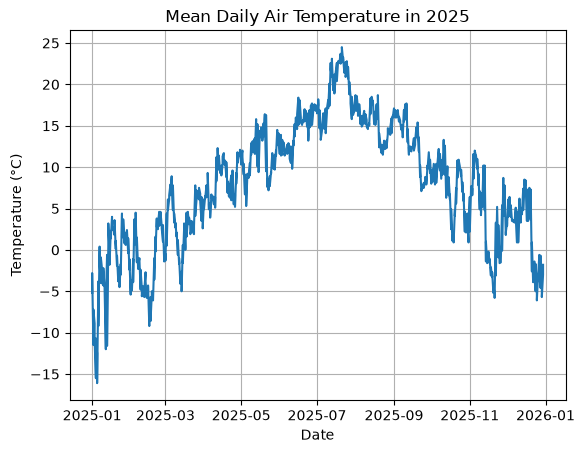

Statistic            Temperature (°C)
-------------------------------------
Mean                             7.90
Median                           8.35
Minimum                        -16.10
Maximum                         24.50


In [71]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Read the client ID from a file
with open("../../frost_client_id.txt", "r") as file:
    client_id = file.read().strip()

# Define endpoint and parameters
endpoint = "https://frost.met.no/observations/v0.jsonld"
parameters = {
    "sources": "SN17850",
    "elements": "mean(air_temperature P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

# Issue an HTTP GET request
r = requests.get(endpoint, params=parameters, auth=(client_id, ""))

# Extract JSON data
json = r.json()

# Check if the request worked, print out any errors
if r.status_code == 200:
    data = json["data"]
    print("Data retrieved from frost.met.no!")
else:
    print("Error! Returned status code %s" % r.status_code)
    print("Message: %s" % json["error"]["message"])
    print("Reason: %s" % json["error"]["reason"])

# This will return a Dataframe with all of the observations in a table format
df = pd.DataFrame()
rows = []
for i in range(len(data)):
    row = pd.DataFrame(data[i]["observations"])
    row["referenceTime"] = data[i]["referenceTime"]
    row["sourceId"] = data[i]["sourceId"]
    rows.append(row)

df = pd.concat(rows, ignore_index=True)

# Extract temperatures and dates
temperatures = df["value"]

dates = pd.to_datetime(df["referenceTime"])

# Plot the data
plt.plot(dates, temperatures)

# Add labels and title to the plot
plt.title("Mean Daily Air Temperature in 2025")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.show()

# Calculate statistics
mean_temp = temperatures.mean()
median_temp = temperatures.median()
min_temp = temperatures.min()
max_temp = temperatures.max()

# Print the statistics in a formatted table
print(f"{'Statistic':<20} {'Temperature (°C)':>16}")
print("-" * 37)
print(f"{'Mean':<20} {mean_temp:>16.2f}")
print(f"{'Median':<20} {median_temp:>16.2f}")
print(f"{'Minimum':<20} {min_temp:>16.2f}")
print(f"{'Maximum':<20} {max_temp:>16.2f}")


In this task we used Frost API to retrive data for mean air temperature for 2025, and plot it using matplotlib libary. 

The graph shows that the temperature was colder during the winter season where the lowest piont was -16.10°C. If we look at the sping and summer season, we can see that the temperature gradually increased, and peaked at 24.50°C. After summer the temperature started to decrease again trough fall and winter.

The statistics shows that the mean temperature for the year was 7.90°C, while the median temperature was 8.35°C. The small difference between the mean and median indicate that the temperature was relatively well balanced througout the year.

## **Task 2**

Data retrieved from frost.met.no!


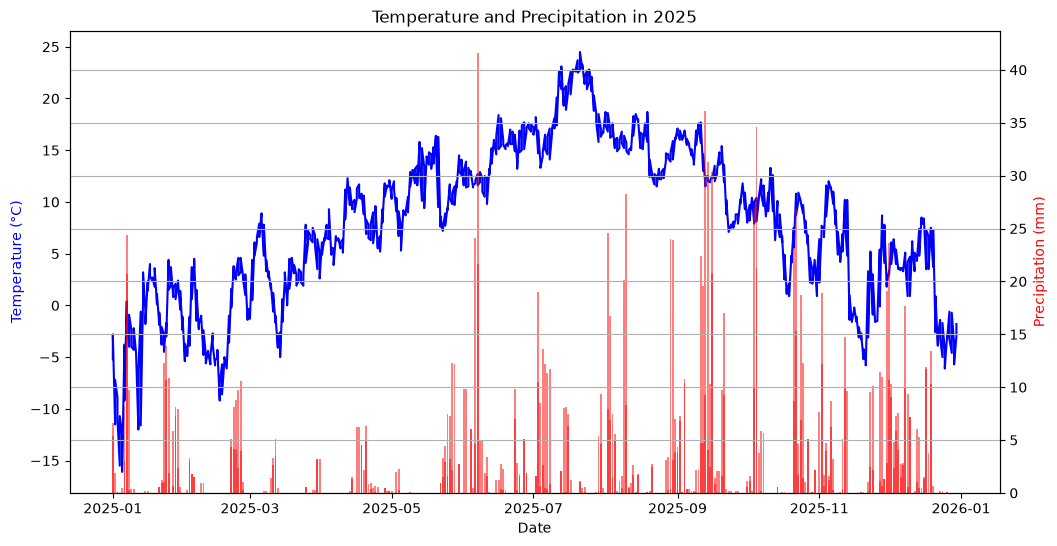

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Read the client ID from a file
with open("../../frost_client_id.txt", "r") as file:
    client_id = file.read().strip()

# Define endpoint and parameters
endpoint = "https://frost.met.no/observations/v0.jsonld"
parameters = {
    "sources": "SN17850",
    "elements": "mean(air_temperature P1D),sum(precipitation_amount P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

# Issue an HTTP GET request
r = requests.get(endpoint, params=parameters, auth=(client_id, ""))

# Extract JSON data
json = r.json()

# Check if the request worked, print out any errors
if r.status_code == 200:
    data = json["data"]
    print("Data retrieved from frost.met.no!")
else:
    print("Error! Returned status code %s" % r.status_code)
    print("Message: %s" % json["error"]["message"])
    print("Reason: %s" % json["error"]["reason"])

# This will return a Dataframe with all of the observations in a table format
df = pd.DataFrame()
rows = []
for i in range(len(data)):
    row = pd.DataFrame(data[i]["observations"])
    row["referenceTime"] = data[i]["referenceTime"]
    row["sourceId"] = data[i]["sourceId"]
    rows.append(row)

df = pd.concat(rows, ignore_index=True)

# Extract temperatures and precipitation data
temperatures = df[df["elementId"] == "mean(air_temperature P1D)"]["value"]
temperature_dates = pd.to_datetime(
    df[df["elementId"] == "mean(air_temperature P1D)"]["referenceTime"]
)

precipitations = df[df["elementId"] == "sum(precipitation_amount P1D)"]["value"]
precipitation_dates = pd.to_datetime(
    df[df["elementId"] == "sum(precipitation_amount P1D)"]["referenceTime"]
)

# Plot the data with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Temperature on the left y-axis
ax1.plot(temperature_dates, temperatures, color="blue", label="Temperature")
ax1.set_xlabel("Date")
ax1.set_ylabel("Temperature (°C)", color="blue")

# Create a new y-axis
ax2 = ax1.twinx()

# Precipitation on the right y-axis
ax2.bar(
    precipitation_dates, precipitations, color="red", alpha=0.5, label="Precipitation"
)
ax2.set_ylabel("Precipitation (mm)", color="red")

plt.title("Temperature and Precipitation in 2025")
plt.grid(True)
plt.show()


In this task we used Frost API to retrive data for mean air temperature and daily precipitation data for 2025. In order to display both datasets in a clear way, where temperature was displayed using a blue line plot, while precipitation was displayed using red bars plot, and since the two messurements use different units (°C and mm), two seperate y-axes were used.

The temperatre data follows the same sesonal pattern observed in Task 1, with temperature increasing from winter to summer before decreasing again towards the end of the year. The precipitation data on the other hand shows that rainfall was not evenly distributed throughout the year. Many days had little to no precipitation, while a few days did, in a few cases the value exceeded 40 mm.

## **Task 3**

Data retrieved from frost.met.no!
Data retrieved from frost.met.no!


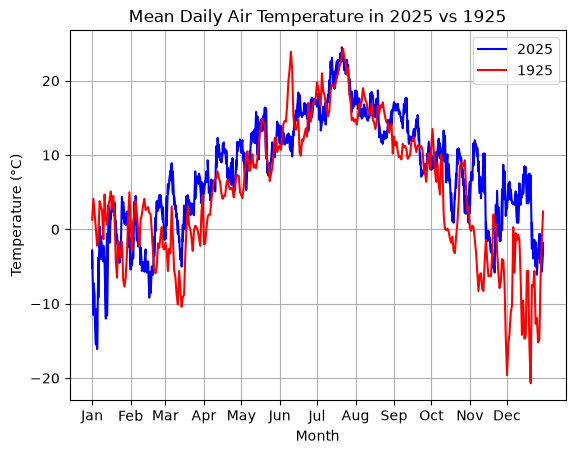

Statistic                           Temperature (°C)
-------------------------------------------------------
Year                             2025             1925
-------------------------------------------------------
Mean                             7.90             5.31
Median                           8.35             5.30
Minimum                        -16.10           -20.70
Maximum                         24.50            24.30


In [80]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Read the client ID from a file
with open("../../frost_client_id.txt", "r") as file:
    client_id = file.read().strip()

# Define endpoint and parameters
endpoint = "https://frost.met.no/observations/v0.jsonld"
parameters_2025 = {
    "sources": "SN17850",
    "elements": "mean(air_temperature P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

parameters_1925 = {
    "sources": "SN17850",
    "elements": "mean(air_temperature P1D)",
    "referencetime": "1925-01-01/1925-12-31",
}

# Issue an HTTP GET request
r_2025 = requests.get(endpoint, params=parameters_2025, auth=(client_id, ""))
r_1925 = requests.get(endpoint, params=parameters_1925, auth=(client_id, ""))

# Extract JSON data
json_2025 = r_2025.json()
json_1925 = r_1925.json()

# Check if the request worked, print out any errors
if r_2025.status_code == 200:
    data_2025 = json_2025["data"]
    print("Data retrieved from frost.met.no!")
else:
    print("Error! Returned status code %s" % r_2025.status_code)
    print("Message: %s" % json_2025["error"]["message"])
    print("Reason: %s" % json_2025["error"]["reason"])

# For the 1925 data
if r_1925.status_code == 200:
    data_1925 = json_1925["data"]
    print("Data retrieved from frost.met.no!")
else:
    print("Error! Returned status code %s" % r_1925.status_code)
    print("Message: %s" % json_1925["error"]["message"])
    print("Reason: %s" % json_1925["error"]["reason"])

# This will return a Dataframe with all of the observations in a table format
df_2025 = pd.DataFrame()
df_1925 = pd.DataFrame()
rows_2025 = []
rows_1925 = []
for i in range(len(data_2025)):
    row = pd.DataFrame(data_2025[i]["observations"])
    row["referenceTime"] = data_2025[i]["referenceTime"]
    row["sourceId"] = data_2025[i]["sourceId"]
    rows_2025.append(row)

for i in range(len(data_1925)):
    row = pd.DataFrame(data_1925[i]["observations"])
    row["referenceTime"] = data_1925[i]["referenceTime"]
    row["sourceId"] = data_1925[i]["sourceId"]
    rows_1925.append(row)

df_2025 = pd.concat(rows_2025, ignore_index=True)
df_1925 = pd.concat(rows_1925, ignore_index=True)

# Extract temperatures and dates
temperatures_2025 = df_2025["value"]
temperatures_1925 = df_1925["value"]

dates_2025 = pd.to_datetime(df_2025["referenceTime"])
dates_1925 = pd.to_datetime(df_1925["referenceTime"])

days_2025 = dates_2025.dt.dayofyear
days_1925 = dates_1925.dt.dayofyear

# Plot the data
plt.plot(days_2025, temperatures_2025, label="2025", color="blue")
plt.plot(days_1925, temperatures_1925, label="1925", color="red")

# Add labels and title to the plot
plt.title("Mean Daily Air Temperature in 2025 vs 1925")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()

# Change x-axis from day numbers to months
month_positions = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
plt.xticks(month_positions, month_names)


plt.show()

# Calculate statistics
mean_temp_2025 = temperatures_2025.mean()
median_temp_2025 = temperatures_2025.median()
min_temp_2025 = temperatures_2025.min()
max_temp_2025 = temperatures_2025.max()

mean_temp_1925 = temperatures_1925.mean()
median_temp_1925 = temperatures_1925.median()
min_temp_1925 = temperatures_1925.min()
max_temp_1925 = temperatures_1925.max()

# Print the statistics in a formatted table
print(f"{'Statistic':<20} {'Temperature (°C)':>31}")
print("-" * 55)
print(f"{'Year':<20} {'2025':>16} {'1925':>16}")
print("-" * 55)
print(f"{'Mean':<20} {mean_temp_2025:>16.2f} {mean_temp_1925:>16.2f}")
print(f"{'Median':<20} {median_temp_2025:>16.2f} {median_temp_1925:>16.2f}")
print(f"{'Minimum':<20} {min_temp_2025:>16.2f} {min_temp_1925:>16.2f}")
print(f"{'Maximum':<20} {max_temp_2025:>16.2f} {max_temp_1925:>16.2f}")


In this task, we reuse the code from Task 1 to additionally retrieve temperature data from 1925. We use the same approach for retrieving and processing the data, but change the date range to obtain observations from 1925.

We plot the daily mean temperatures for 1925 and 2025 on the same graph. To make the two years directly comparable, the dates are converted to "day of year", meaning that the same calendar dates from each year are plotted at approximately the same position on the x-axis. To make the graph easier to read, we replace the numerical day-of-year labels with month names.

We also calculate the mean, median, minimum, and maximum temperatures for both years and display them in a formatted statistics table.

The graph shows that the temperature patterns in 1925 and 2025 are somewhat similar, although temperatures are generally lower in 1925. One notable exception is a period of relatively high temperatures in June 1925.

The statistics support what can be observed in the graph. The mean temperature was approximately 2.6 °C lower in 1925 than in 2025. A similar difference can be seen in the median and minimum temperatures. However, the maximum temperatures are relatively similar between the two years, which appears to be influenced by the high temperatures observed in June 1925.


## **Task 4**

In [81]:
import requests
import pandas as pd
import yaml

# Read the client ID from a file
with open("../../frost_client_id.txt", "r") as file:
    client_id = file.read().strip()


def heatwave_summary_to_yml(station_id, station_name, year):
    """
    Retrieve heatwave data for a given station and year, and save it to a YAML file.
    """
    # Define endpoint and parameters
    endpoint = "https://frost.met.no/observations/v0.jsonld"
    parameters = {
    "sources": f"{station_id}",
    "elements": "max(air_temperature P1D)",
    "referencetime": f"{year}-01-01/{year}-12-31",
    }

    # Issue an HTTP GET request
    r = requests.get(endpoint, params=parameters, auth=(client_id, ""))

    # Extract JSON data
    json = r.json()

    # Check if the request worked, print out any errors
    if r.status_code == 200:
        data = json["data"]
        print("Data retrieved from frost.met.no!")
    else:
        print("Error! Returned status code %s" % r.status_code)
        print("Message: %s" % json["error"]["message"])
        print("Reason: %s" % json["error"]["reason"])

    # This will return a Dataframe with all of the observations in a table format
    df = pd.DataFrame()
    rows = []
    for i in range(len(data)):
        row = pd.DataFrame(data[i]["observations"])
        row["referenceTime"] = data[i]["referenceTime"]
        row["sourceId"] = data[i]["sourceId"]
        rows.append(row)

    # Concatenate all rows into a single DataFrame
    df = pd.concat(rows, ignore_index=True)

    # Convert the referenceTime column to datetime format
    df["referenceTime"] = pd.to_datetime(df["referenceTime"]) 

    # Calculate daily maximum temperatures (2 observations per day, so we take the max)
    daily_temperatures = df.groupby(df["referenceTime"].dt.date)["value"].max()

    # Prepare the heatwave summary data structure
    heatwave_data = {
            "dates" : [],
            "station_id": station_id,
            "station_name": station_name,
            "year": year,
        }

    # Count consecutive days with temperatures >= 27°C, and store the start and end dates of heatwaves
    number_of_days = 0
    start_date = None

    for date, temp in daily_temperatures.items():

        if temp >= 27:
            number_of_days += 1

            if number_of_days == 1:
                start_date = date

        else:
            if number_of_days >= 5:
                end_date = date - pd.Timedelta(days=1)

                heatwave_data["dates"].append(f"{start_date.strftime('%Y-%m-%d')} - {end_date.strftime('%Y-%m-%d')}")

            number_of_days = 0
            start_date = None

    # Save the heatwave summary to a YAML file
    with open(f"heatwave_summary_{station_id}_{year}.yml", "w") as file:
        yaml.dump(heatwave_data, file)

    print(f"Heatwave summary saved to heatwave_summary_{station_id}_{year}.yml")

heatwave_summary_to_yml("SN17850", r"\xC5s", 2025)


Data retrieved from frost.met.no!
Heatwave summary saved to heatwave_summary_SN17850_2025.yml


In this task, we define a function with the purpose of retrieving heatwave data for a given weather station and year and saving the results to a YAML file.

We do this by reusing code from Task 1 and making the station ID and year in the API parameters into variables. We also change the requested element to the maximum daily air temperature. Since the retrieved data contains two observations per day, we group the observations by date and use the highest value as the daily maximum temperature.

A heatwave is defined as a consecutive period of five or more days where the maximum temperature is equal to or above 27 °C. Using the calculated daily maximum temperatures, we count the number of consecutive days that meet this requirement. When a heatwave is detected, its start and end dates are stored and saved to the YAML file along with information about the station and year.

Using station SN17850 in 2025 as an example, the program detected one heatwave, lasting from July 16 to July 22. This corresponds to seven consecutive days with a daily maximum temperature of at least 27 °C.

## **Task 5**

Data retrieved from frost.met.no!


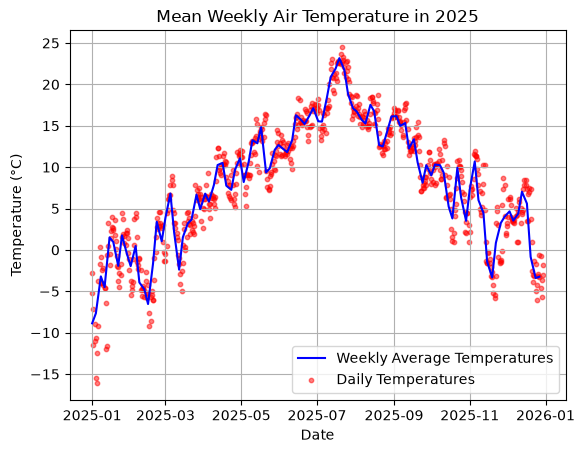

In [79]:
import requests
import pandas as pd
import matplotlib.pyplot as plt


def week_average_temperature(list_of_temperatures):
    """
    Calculate the average temperature for each week given a list of daily temperatures.

    Parameters:
    list_of_temperatures (list): A list of daily temperatures.

    Returns:
    list: A list of average temperatures for each week.
    """
    weekly_averages = []
    for i in range(0, len(list_of_temperatures), 7):
        week = list_of_temperatures[i : i + 7]
        if len(week) == 7:  # Ensure we have a full week
            weekly_average = sum(week) / len(week)
            weekly_averages.append(weekly_average)
    return weekly_averages


# Read the client ID from a file
with open("../../frost_client_id.txt", "r") as file:
    client_id = file.read().strip()

# Define endpoint and parameters
endpoint = "https://frost.met.no/observations/v0.jsonld"
parameters = {
    "sources": "SN17850",
    "elements": "mean(air_temperature P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

# Issue an HTTP GET request
r = requests.get(endpoint, params=parameters, auth=(client_id, ""))

# Extract JSON data
json = r.json()

# Check if the request worked, print out any errors
if r.status_code == 200:
    data = json["data"]
    print("Data retrieved from frost.met.no!")
else:
    print("Error! Returned status code %s" % r.status_code)
    print("Message: %s" % json["error"]["message"])
    print("Reason: %s" % json["error"]["reason"])

# This will return a Dataframe with all of the observations in a table format
df = pd.DataFrame()
rows = []
for i in range(len(data)):
    row = pd.DataFrame(data[i]["observations"])
    row["referenceTime"] = data[i]["referenceTime"]
    row["sourceId"] = data[i]["sourceId"]
    rows.append(row)

df = pd.concat(rows, ignore_index=True)

# Extract temperatures and dates
temperatures = df["value"]

dates = pd.to_datetime(df["referenceTime"])

# Calculate weekly averages
weekly_averages = week_average_temperature(temperatures)
weekly_dates = dates[::7][: len(weekly_averages)]  # Get the corresponding dates for weekly averages

# Plot the data
plt.plot(weekly_dates, weekly_averages, color="blue", label="Weekly Average Temperatures")
plt.scatter(dates, temperatures, color="red", s=10, alpha=0.5, label="Daily Temperatures")

# Add labels and title to the plot
plt.title("Mean Weekly Air Temperature in 2025")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()

plt.show()


In this task, a function was created to calculate the 7-day moving average temperature based on the daily mean temperatures collected in Task 1.

The graph shows the daily temperatures as red points and the 7-day moving average as blue line. The daily temperature measurements shows significent fluctuauions from day to day, sepecially during the winter season where temperature change rapidly. During summer season, the daily temperatures are more stable and tend to follow the moving average line more closely.